In [ ]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import random

## Image Show Modules (cv and matplotlib)

In [ ]:
def cv_show(im,msg):
    cv2.imshow(msg,im)
    cv2.waitKey(0)
    cv2.destroyAllWindows()	

def plt_show(im):
    plt.axis("off")
    plt.imshow(im, cmap="gray")
    plt.show()

## Image Histogram

In [ ]:
def histogram(f):
    m, n = f.shape
    h = [0.0] * 256
    for i in range(m):
        for j in range(n):
            h[f[i, j]]+=1
    return np.array(h, dtype='uint16')

## Intermean Method to repeat calculate mean values between 2 histogram groups

In [ ]:
def float2int(x):
    if x - math.floor(x) >= 0.5:
        result = math.ceil(x)
    else:
        result = math.floor(x)
    return result

In [ ]:
def otsu(hist, st, en):
    prob = np.zeros_like(hist, dtype='float16')
    tot = np.sum(hist[st:en])
    prob[st:en] = hist[st:en]/tot
    coef_max = -1
    thr = -1
    for t in range(st+1, en):
        w0 = np.sum(prob[st:t]) + 0.00000001
        w1 = np.sum(prob[t:en]) + 0.00000001
        i0 = np.array([i for i in range(st, t)])
        i1 = np.array([i for i in range(t, en)])
        u0 = np.sum(i0*prob[st:t])/w0
        u1 = np.sum(i1*prob[t:en])/w1

        coef = (w0*w1)*np.power(u0-u1,2)
        if  coef > coef_max:
            coef_max = coef
            thr = t
    return thr

## Main Process
1. Read Image

In [ ]:
img = cv2.imread("gray2.png", cv2.IMREAD_GRAYSCALE)
hist = histogram(img)

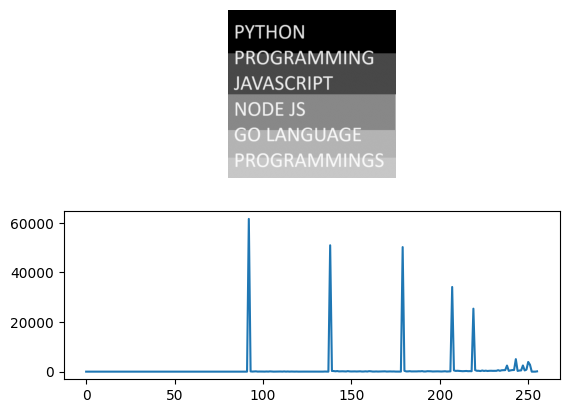

In [ ]:
plt.subplot(2, 1, 1)
plt.axis("off")
plt.imshow(img, cmap="gray")

plt.subplot(2, 1, 2)
plt.plot(hist)

plt.show()

In [ ]:
threshs = otsu(hist, 0, 256)
print(threshs)

161


C:\Users\Joom\AppData\Local\Temp\ipykernel_6412\1652148370.py:12: RuntimeWarning: invalid value encountered in scalar divide
  u0 = np.sum(i0*prob[st:t])/w0


In [ ]:

out = np.zeros_like(img, dtype= 'uint8')
out[img > threshs] = 255
plt_show(out)

In [ ]:
def plot_histogram(hist, st, en):
    plt.axis("off")
    plt.plot(hist[st:en])
    plt.show()

def intermean_loop(hist):
    st, en = 0, 256
    for inx in range(4):
        plot_histogram(hist,st,en)
        threshs = otsu(hist, st, en)
        st = threshs+1
    return threshs
        
   

In [ ]:
threshs = otsu(hist, 0, 256)
print(threshs)

In [ ]:
out = np.zeros_like(img, dtype= 'uint8')
out[img > threshs] = 255
plt_show(out)